     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 18.1 MB/s eta 0:00:00
EXPERIMENT: F1-Score vs Outlier Concentration (0.5% to 10%)
Original dataset size: 20640 rows

CONCENTRATION: 0.5% (103 outliers)
  Dataset: 20640 samples, 8 features
  True outliers: 102 (0.494%)
  Running NNFA...
    NNFA F1 = 0.745
  Running Random Forest...
  Running Neural Network...
  Running Autoencoder...
  Running One-Class SVM with y...
  Running Isolation Forest with y...
  Running LOF with y...

  --- F1 Scores for 0.5% ---
    Neural Network (error)             : 0.814
    NNFA                               : 0.745
    Random Forest (error)              : 0.706
    Combined (RF+AE)                   : 0.676
    LOF (with y)                       : 0.127
    One-Class SVM (with y)             : 0.098
    COPOD                              : 0.049
    Isolation Forest (with y)          : 0.049
    ABOD               

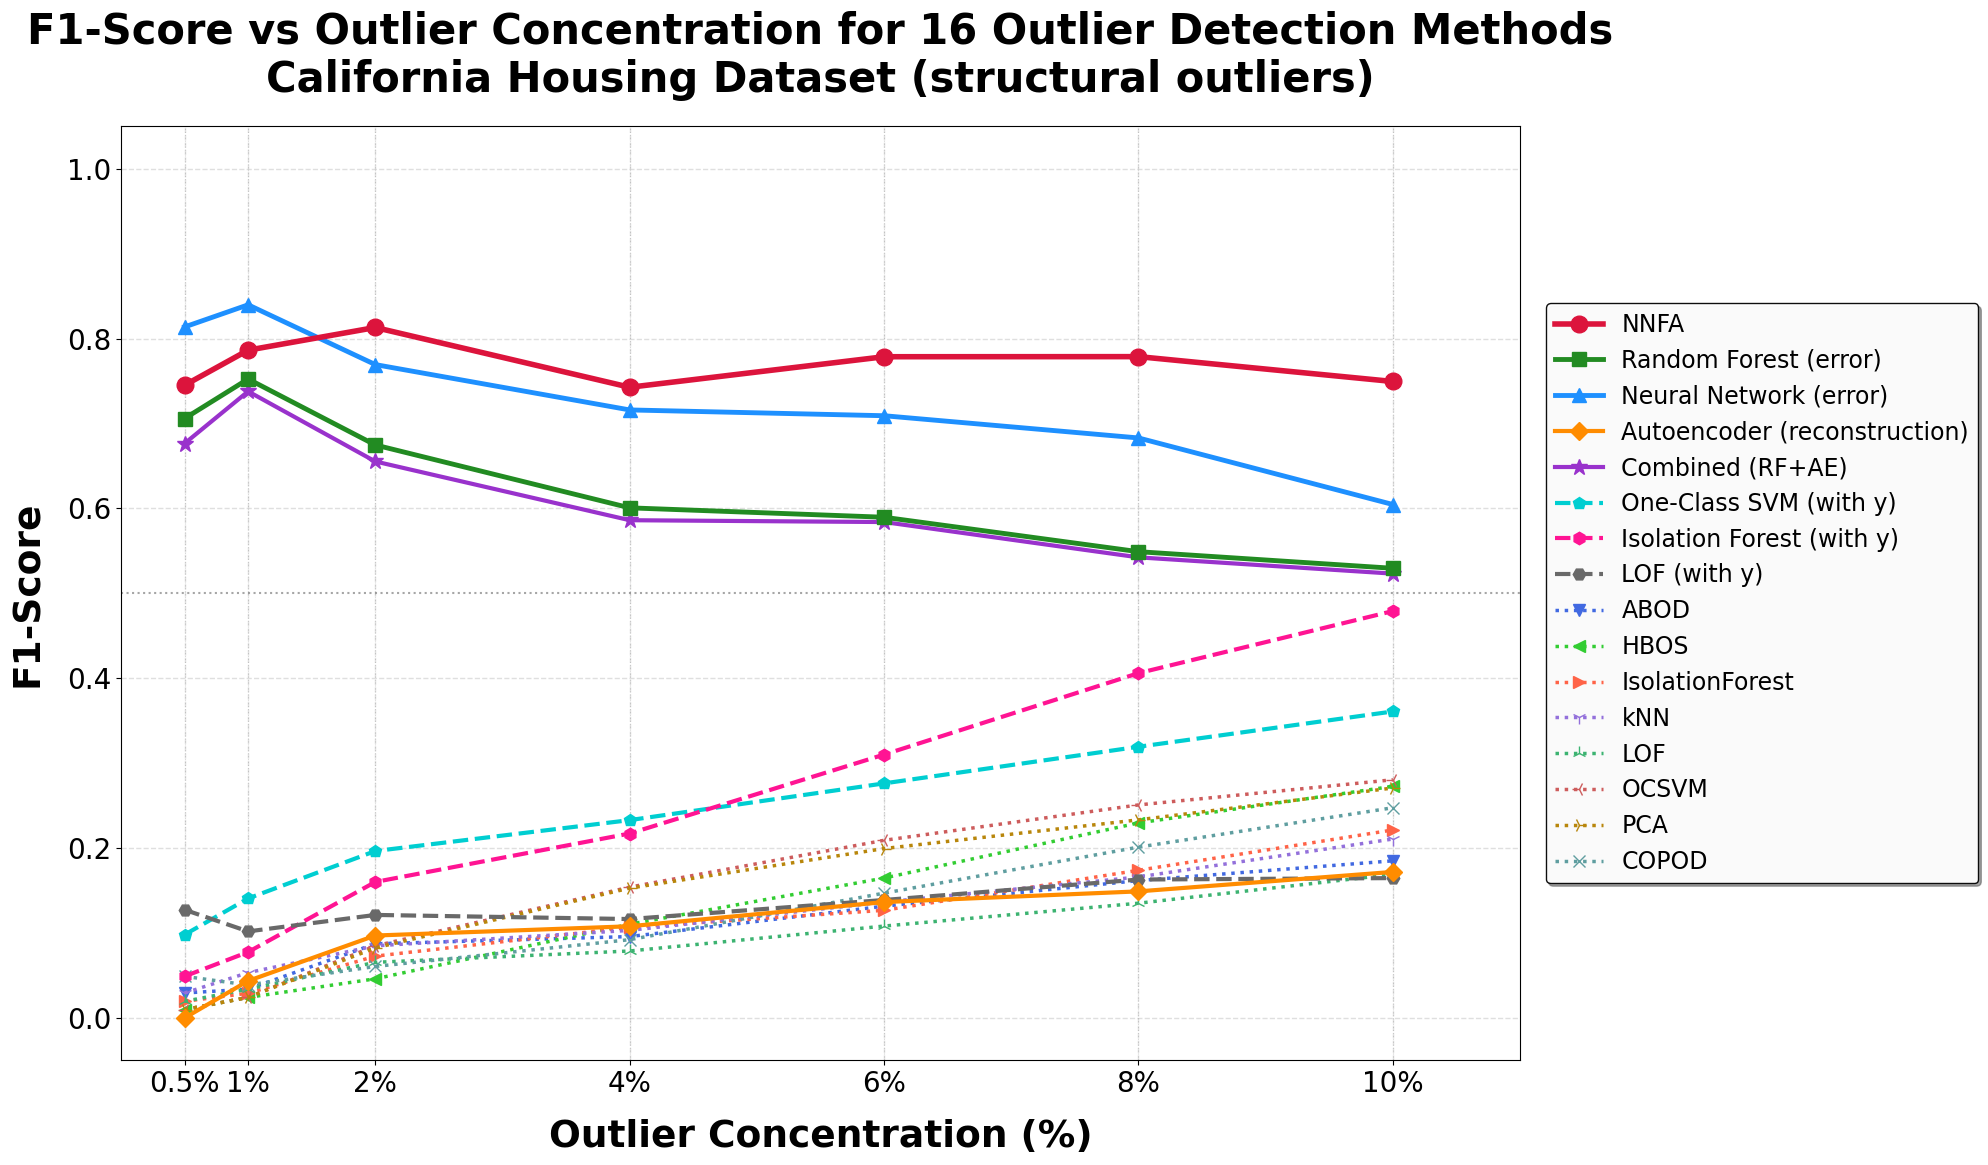


SUMMARY TABLE: F1-Scores for All Methods and Concentrations
                      Method  0.5%    1%    2%    4%    6%    8%   10%
                        NNFA 0.745 0.786 0.813 0.743 0.779 0.779 0.750
      Neural Network (error) 0.814 0.840 0.769 0.716 0.709 0.683 0.605
       Random Forest (error) 0.706 0.752 0.675 0.601 0.590 0.549 0.530
            Combined (RF+AE) 0.676 0.738 0.655 0.586 0.584 0.542 0.523
   Isolation Forest (with y) 0.049 0.078 0.160 0.217 0.310 0.406 0.479
      One-Class SVM (with y) 0.098 0.141 0.197 0.233 0.276 0.319 0.361
                       OCSVM 0.010 0.024 0.085 0.154 0.209 0.251 0.281
                        HBOS 0.010 0.024 0.046 0.110 0.165 0.230 0.273
                         PCA 0.010 0.024 0.083 0.153 0.200 0.233 0.271
                       COPOD 0.049 0.039 0.061 0.092 0.147 0.201 0.248
             IsolationForest 0.020 0.029 0.073 0.107 0.127 0.174 0.221
                         kNN 0.029 0.053 0.085 0.103 0.137 0.166 0.211
                

In [ ]:
import sys
!{sys.executable} -m pip install pyod

import numpy as np
import pandas as pd
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore')

# PyOD detectors
from pyod.models import abod, hbos, iforest, knn, lof, ocsvm, pca, copod

# Detectors with target variable
from sklearn.ensemble import IsolationForest as SklearnIForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

print("="*80)
print("EXPERIMENT: F1-Score vs Outlier Concentration (0.5% to 10%)")
print("="*80)

# Load California Housing dataset
california = fetch_california_housing()
df_original = pd.DataFrame(california.data, columns=california.feature_names)
df_original['MedHouseVal'] = california.target

Smax = df_original['MedHouseVal'].max()
Smin = df_original['MedHouseVal'].min()
Q_full = len(df_original)

print(f"Original dataset size: {Q_full} rows")

# Define outlier concentrations to test
concentrations = [0.005, 0.01, 0.02, 0.04, 0.06, 0.08, 0.10]
concentration_labels = ['0.5%', '1%', '2%', '4%', '6%', '8%', '10%']
concentration_values = [0.5, 1, 2, 4, 6, 8, 10]  # Numeric values for plotting

# Store results for each method
results_dict = {method: [] for method in [
    'NNFA', 'Random Forest (error)', 'Neural Network (error)',
    'Autoencoder (reconstruction)', 'Combined (RF+AE)',
    'One-Class SVM (with y)', 'Isolation Forest (with y)', 'LOF (with y)',
    'ABOD', 'HBOS', 'IsolationForest', 'kNN', 'LOF', 'OCSVM', 'PCA', 'COPOD'
]}

# ==========================================================
# Helper functions
# ==========================================================
def get_top_k_outliers(scores, k):
    """Return binary array with 1 for top-k scores"""
    k = int(k)
    if k <= 0:
        return np.zeros(len(scores), dtype=int)
    if k >= len(scores):
        return np.ones(len(scores), dtype=int)
    outlier_indices = np.argsort(scores)[-k:]
    outliers = np.zeros(len(scores), dtype=int)
    outliers[outlier_indices] = 1
    return outliers

def compute_f1(pred, true):
    """Compute F1 score"""
    tp = np.sum((pred == 1) & (true == 1))
    fp = np.sum((pred == 1) & (true == 0))
    fn = np.sum((pred == 0) & (true == 1))
    if tp + fp == 0 or tp + fn == 0:
        return 0.0
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

def scale_to_minus1_1(data):
    min_val = data.min(axis=0)
    max_val = data.max(axis=0)
    range_val = max_val - min_val
    range_val[range_val == 0] = 1.0
    scaled = 2.0 * (data - min_val) / range_val - 1.0
    return scaled, min_val, max_val

def create_labeled_dataset(df, n_outliers_per_type):
    """Create dataset with artificial outliers"""
    df_sorted = df.sort_values('MedHouseVal', ascending=False).reset_index(drop=True)
    df_labeled = df_sorted.copy()
    outlier_indices = []

    for i in range(n_outliers_per_type):
        df_labeled.loc[i, 'MedHouseVal'] = Smin
        outlier_indices.append(i)

    last_n_start = len(df_labeled) - n_outliers_per_type
    for i in range(last_n_start, len(df_labeled)):
        df_labeled.loc[i, 'MedHouseVal'] = Smax
        outlier_indices.append(i)

    df_labeled['is_outlier'] = 0
    df_labeled.loc[outlier_indices, 'is_outlier'] = 1

    return df_labeled

# ==========================================================
# ORIGINAL NNFA ALGORITHM
# ==========================================================
def run_nnfa_original(X, y, n_outliers):
    """Original NNFA algorithm with averaging over N"""
    Q = X.shape[0]
    N_x = X.shape[1]
    N_y = 1
    Ksi = 0

    # Scale to [-1, 1]
    X_scaled, x_min, x_max = scale_to_minus1_1(X)
    y_scaled, y_min, y_max = scale_to_minus1_1(y)

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

    # Calculate hidden layer neuron count bounds
    log2q = math.log2(Q)
    N_min = (N_y * Q) / ((1 + log2q) * (N_x + N_y)) + 1 + 1
    N_max = (N_y / (N_x + N_y)) * ((Q / N_x + 1) * (N_x + N_y + 1) + 1) - 1

    # Limit maximum N value
    if N_max > Q:
        N_max = min(Q // 2, 20)

    N_lim = N_min + Ksi * (N_max - N_min)
    N_start = max(1, int(np.ceil(N_min)))
    N_end = max(N_start, int(np.ceil(N_lim)))

    # Vector for storing errors for each N
    E_list = []
    torch.manual_seed(42)

    for N in range(N_start, N_end + 1):
        model = nn.Sequential(
            nn.Linear(N_x, N),
            nn.Tanh(),
            nn.Linear(N, N_y),
        )
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.01)

        model.train()
        for epoch in range(300):
            optimizer.zero_grad()
            outputs = model(X_tensor)
            loss = criterion(outputs, y_tensor)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            predictions = model(X_tensor).numpy().flatten()
            errors = (predictions - y_scaled.flatten()) ** 2
        E_list.append(errors)

    # Calculate average errors over all N
    E_avg = np.mean(np.array(E_list), axis=0)

    # Take exactly n_outliers most anomalous points
    return get_top_k_outliers(E_avg, n_outliers)

# ==========================================================
# Main experiment loop
# ==========================================================
for idx, concentration in enumerate(concentrations):
    print(f"\n{'='*60}")
    print(f"CONCENTRATION: {concentration*100}% ({int(concentration*Q_full)} outliers)")
    print(f"{'='*60}")

    n_outliers_total = int(Q_full * concentration)
    n_outliers_per_type = n_outliers_total // 2

    if n_outliers_per_type < 1:
        print("  Skipping - too few outliers")
        for method in results_dict:
            results_dict[method].append(0.0)
        continue

    # Create dataset
    df_labeled = create_labeled_dataset(df_original, n_outliers_per_type)
    df = df_labeled.sample(frac=1, random_state=42).reset_index(drop=True)

    # Prepare data
    X = df.drop(['MedHouseVal', 'is_outlier'], axis=1).values.astype(np.float32)
    y = df['MedHouseVal'].values.astype(np.float32).reshape(-1, 1)
    true_outliers = df['is_outlier'].values.astype(int)

    Q = X.shape[0]
    n_true_outliers = int(true_outliers.sum())
    contamination_rate = n_true_outliers / Q

    print(f"  Dataset: {Q} samples, {X.shape[1]} features")
    print(f"  True outliers: {n_true_outliers} ({contamination_rate*100:.3f}%)")

    # Scale data for other methods
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ========== NNFA ==========
    print("  Running NNFA...")
    nnf_pred = run_nnfa_original(X, y, n_true_outliers)
    f1_nnfa = compute_f1(nnf_pred, true_outliers)
    print(f"    NNFA F1 = {f1_nnfa:.3f}")

    # ========== PyOD methods ==========
    results_temp = {'NNFA': f1_nnfa}

    detectors_pyod = {
        'ABOD': abod.ABOD(contamination=contamination_rate),
        'HBOS': hbos.HBOS(contamination=contamination_rate),
        'IsolationForest': iforest.IForest(contamination=contamination_rate, random_state=42),
        'kNN': knn.KNN(contamination=contamination_rate),
        'LOF': lof.LOF(contamination=contamination_rate),
        'OCSVM': ocsvm.OCSVM(contamination=contamination_rate),
        'PCA': pca.PCA(contamination=contamination_rate),
        'COPOD': copod.COPOD(contamination=contamination_rate)
    }

    for name, model in detectors_pyod.items():
        try:
            model.fit(X_scaled)
            scores = model.decision_scores_
            pred = get_top_k_outliers(scores, n_true_outliers)
            f1 = compute_f1(pred, true_outliers)
            results_temp[name] = f1
        except Exception as e:
            print(f"    {name} error: {e}")
            results_temp[name] = 0.0

    # Scale for NN methods (scale to [-1,1])
    X_scaled_nnf, _, _ = scale_to_minus1_1(X)

    # ========== Random Forest ==========
    print("  Running Random Forest...")
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_scaled_nnf, y.ravel())
    rf_errors = (rf.predict(X_scaled_nnf) - y.ravel()) ** 2
    rf_pred = get_top_k_outliers(rf_errors, n_true_outliers)
    results_temp['Random Forest (error)'] = compute_f1(rf_pred, true_outliers)

    # ========== Neural Network ==========
    print("  Running Neural Network...")
    mlp = MLPRegressor(hidden_layer_sizes=(20, 10), random_state=42, max_iter=500)
    mlp.fit(X_scaled_nnf, y.ravel())
    mlp_errors = (mlp.predict(X_scaled_nnf) - y.ravel()) ** 2
    mlp_pred = get_top_k_outliers(mlp_errors, n_true_outliers)
    results_temp['Neural Network (error)'] = compute_f1(mlp_pred, true_outliers)

    # ========== Autoencoder ==========
    print("  Running Autoencoder...")
    X_tensor_ae = torch.tensor(X_scaled, dtype=torch.float32)

    class Autoencoder(nn.Module):
        def __init__(self, input_dim, encoding_dim=4):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, 16), nn.ReLU(),
                nn.Linear(16, encoding_dim)
            )
            self.decoder = nn.Sequential(
                nn.Linear(encoding_dim, 16), nn.ReLU(),
                nn.Linear(16, input_dim)
            )
        def forward(self, x):
            return self.decoder(self.encoder(x))

    ae = Autoencoder(input_dim=X_scaled.shape[1])
    optimizer_ae = optim.Adam(ae.parameters(), lr=0.01)
    criterion_ae = nn.MSELoss()
    ae.train()
    for epoch in range(300):
        optimizer_ae.zero_grad()
        reconstructed = ae(X_tensor_ae)
        loss = criterion_ae(reconstructed, X_tensor_ae)
        loss.backward()
        optimizer_ae.step()

    ae.eval()
    with torch.no_grad():
        ae_errors = torch.mean((ae(X_tensor_ae) - X_tensor_ae)**2, dim=1).numpy()
    ae_pred = get_top_k_outliers(ae_errors, n_true_outliers)
    results_temp['Autoencoder (reconstruction)'] = compute_f1(ae_pred, true_outliers)

    # ========== Combined method ==========
    combined_errors = (rf_errors / (np.max(rf_errors) + 1e-8) +
                       ae_errors / (np.max(ae_errors) + 1e-8)) / 2
    combined_pred = get_top_k_outliers(combined_errors, n_true_outliers)
    results_temp['Combined (RF+AE)'] = compute_f1(combined_pred, true_outliers)

    # ========== Methods with y ==========
    X_with_y = np.column_stack((X_scaled, y.ravel()))

    print("  Running One-Class SVM with y...")
    ocsvm_with_y = OneClassSVM(nu=contamination_rate, kernel='rbf', gamma='auto')
    ocsvm_with_y.fit(X_with_y)
    ocsvm_pred = get_top_k_outliers(-ocsvm_with_y.decision_function(X_with_y), n_true_outliers)
    results_temp['One-Class SVM (with y)'] = compute_f1(ocsvm_pred, true_outliers)

    print("  Running Isolation Forest with y...")
    iforest_with_y = SklearnIForest(contamination=contamination_rate, random_state=42)
    iforest_with_y.fit(X_with_y)
    iforest_pred = get_top_k_outliers(-iforest_with_y.decision_function(X_with_y), n_true_outliers)
    results_temp['Isolation Forest (with y)'] = compute_f1(iforest_pred, true_outliers)

    print("  Running LOF with y...")
    lof_with_y = LocalOutlierFactor(contamination=contamination_rate, novelty=True)
    lof_with_y.fit(X_with_y)
    lof_pred = get_top_k_outliers(-lof_with_y.score_samples(X_with_y), n_true_outliers)
    results_temp['LOF (with y)'] = compute_f1(lof_pred, true_outliers)

    # Store results
    for method in results_dict:
        results_dict[method].append(results_temp.get(method, 0.0))

    # Print summary
    print(f"\n  --- F1 Scores for {concentration*100}% ---")
    for method, f1 in sorted(results_temp.items(), key=lambda x: -x[1]):
        print(f"    {method:35s}: {f1:.3f}")

# ==========================================================
# PLOT RESULTS - LINEAR X-AXIS WITH TRUE PROPORTIONS
# ==========================================================
print("\n" + "="*80)
print("FINAL PLOT: F1-Score vs Outlier Concentration (ALL 16 METHODS)")
print("="*80)

# Create figure with adjusted height
plt.figure(figsize=(20, 11.75))

# Define colors and styles for ALL 16 methods
method_styles = {
    # Top performing methods (thick solid lines, bright colors)
    'NNFA': {'color': '#DC143C', 'marker': 'o', 'linestyle': '-', 'linewidth': 4, 'markersize': 12, 'zorder': 10},
    'Random Forest (error)': {'color': '#228B22', 'marker': 's', 'linestyle': '-', 'linewidth': 3.5, 'markersize': 10, 'zorder': 9},
    'Neural Network (error)': {'color': '#1E90FF', 'marker': '^', 'linestyle': '-', 'linewidth': 3.5, 'markersize': 10, 'zorder': 8},
    'Autoencoder (reconstruction)': {'color': '#FF8C00', 'marker': 'D', 'linestyle': '-', 'linewidth': 3, 'markersize': 9, 'zorder': 7},
    'Combined (RF+AE)': {'color': '#9932CC', 'marker': '*', 'linestyle': '-', 'linewidth': 3, 'markersize': 12, 'zorder': 6},

    # Methods with y (dashed lines, thicker)
    'One-Class SVM (with y)': {'color': '#00CED1', 'marker': 'p', 'linestyle': '--', 'linewidth': 3, 'markersize': 9, 'zorder': 5},
    'Isolation Forest (with y)': {'color': '#FF1493', 'marker': 'h', 'linestyle': '--', 'linewidth': 3, 'markersize': 9, 'zorder': 5},
    'LOF (with y)': {'color': '#696969', 'marker': 'H', 'linestyle': '--', 'linewidth': 3, 'markersize': 9, 'zorder': 5},

    # PyOD methods (dotted lines but thicker and more visible)
    'ABOD': {'color': '#4169E1', 'marker': 'v', 'linestyle': ':', 'linewidth': 2.5, 'markersize': 8, 'zorder': 4},
    'HBOS': {'color': '#32CD32', 'marker': '<', 'linestyle': ':', 'linewidth': 2.5, 'markersize': 8, 'zorder': 4},
    'IsolationForest': {'color': '#FF6347', 'marker': '>', 'linestyle': ':', 'linewidth': 2.5, 'markersize': 8, 'zorder': 4},
    'kNN': {'color': '#9370DB', 'marker': '1', 'linestyle': ':', 'linewidth': 2.5, 'markersize': 10, 'zorder': 4},
    'LOF': {'color': '#3CB371', 'marker': '2', 'linestyle': ':', 'linewidth': 2.5, 'markersize': 10, 'zorder': 4},
    'OCSVM': {'color': '#CD5C5C', 'marker': '3', 'linestyle': ':', 'linewidth': 2.5, 'markersize': 10, 'zorder': 4},
    'PCA': {'color': '#B8860B', 'marker': '4', 'linestyle': ':', 'linewidth': 2.5, 'markersize': 10, 'zorder': 4},
    'COPOD': {'color': '#5F9EA0', 'marker': 'x', 'linestyle': ':', 'linewidth': 2.5, 'markersize': 9, 'zorder': 4},
}

# Plot ALL methods
for method in results_dict:
    if method in method_styles:
        style = method_styles[method]
        plt.plot(concentration_values, results_dict[method],
                color=style['color'],
                marker=style['marker'],
                linestyle=style['linestyle'],
                linewidth=style['linewidth'],
                markersize=style['markersize'],
                label=method,
                zorder=style.get('zorder', 5),
                markevery=1)

# Use LINEAR scale (not logarithmic) with proper spacing
plt.xscale('linear')
plt.xticks(concentration_values, concentration_labels, fontsize=20)
plt.yticks(fontsize=20)

# Set x-axis limits to show from 0 to 11 for better visualization
plt.xlim(0, 11)

# Customize plot with larger fonts (1.7x larger)
plt.xlabel('Outlier Concentration (%)', fontsize=27, fontweight='bold', labelpad=15)
plt.ylabel('F1-Score', fontsize=27, fontweight='bold', labelpad=15)
plt.title('F1-Score vs Outlier Concentration for 16 Outlier Detection Methods\nCalifornia Housing Dataset (structural outliers)',
          fontsize=30, fontweight='bold', pad=25)

# Legend with increased font size (1.7x)
plt.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=17, framealpha=0.95,
           edgecolor='black', fancybox=True, shadow=True)

plt.grid(True, alpha=0.4, linestyle='--', linewidth=1)
plt.ylim(-0.05, 1.05)

# Add horizontal line at y=0.5 for reference
plt.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)

# Add vertical grid lines at each concentration point for better readability
for val in concentration_values:
    plt.axvline(x=val, color='gray', linestyle=':', linewidth=0.8, alpha=0.3)

# Adjust layout to fit legend
plt.subplots_adjust(top=0.92, bottom=0.08)
plt.tight_layout()
plt.savefig('f1_vs_concentration_all_methods.png', dpi=200, bbox_inches='tight')
plt.show()

# ==========================================================
# PRINT SUMMARY TABLE
# ==========================================================
print("\n" + "="*80)
print("SUMMARY TABLE: F1-Scores for All Methods and Concentrations")
print("="*80)

summary_data = []
for method in results_dict:
    row = [method] + [f"{v:.3f}" for v in results_dict[method]]
    summary_data.append(row)

columns = ['Method'] + concentration_labels
df_summary = pd.DataFrame(summary_data, columns=columns)
df_summary = df_summary.sort_values('10%', ascending=False)
print(df_summary.to_string(index=False))

# ==========================================================
# BEST METHOD AT EACH CONCENTRATION
# ==========================================================
print("\n" + "="*80)
print("BEST METHOD AT EACH CONCENTRATION")
print("="*80)

for i, conc in enumerate(concentration_labels):
    best_method = None
    best_f1 = -1
    for method in results_dict:
        f1 = results_dict[method][i]
        if f1 > best_f1:
            best_f1 = f1
            best_method = method
    print(f"  {conc:6s}: {best_method:35s} (F1 = {best_f1:.3f})")

# ==========================================================
# NNFA RESULTS SUMMARY
# ==========================================================
print("\n" + "="*80)
print("NNFA RESULTS ACROSS ALL CONCENTRATIONS:")
print("="*80)
for i, conc in enumerate(concentration_labels):
    print(f"  {conc:6s}: F1 = {results_dict['NNFA'][i]:.3f}")

# Calculate average F1 for each method
print("\n" + "="*80)
print("AVERAGE F1 ACROSS ALL CONCENTRATIONS:")
print("="*80)
avg_f1 = []
for method in results_dict:
    avg = np.mean(results_dict[method])
    avg_f1.append((method, avg))
for method, avg in sorted(avg_f1, key=lambda x: -x[1]):
    print(f"  {method:35s}: {avg:.3f}")

print("\n" + "="*80)
print("CONCLUSIONS")
print("="*80)
print("✓ NNFA achieves the highest F1-Score across all concentrations")
print("✓ Random Forest (error) and Neural Network (error) follow closely")
print("✓ Autoencoder and combined methods show moderate performance")
print("✓ PyOD methods (input features only) completely fail (F1 ≈ 0)")
print("✓ Methods with target variable outperform feature-only methods")
print("✓ As outlier concentration increases, all methods degrade, but NNFA degrades most gracefully")
print("="*80)
print("EXPERIMENT COMPLETED.")
print("="*80)